# EDA 10 v2 — Figure 4.5: mechanism geography with case-study exemplars

**Created 2026-07-29.** Companion to the EDA 12 v5 correspondence map, splitting the
old single figure into two per the revised chapter logic:

| Figure | Section | Fills | Yee markers | Case outlines/labels |
|---|---|---|---|---|
| **4.5 (this notebook)** | end of §4.5 | full six-class mechanism background | **none** | **yes — four cases** |
| 4.6 (EDA 12 v5) | early §4.6 | same fills, same palette | purple SupGen/MainGen | none |

Figure 4.5's job: *show where the mechanism profiles occur and where the
illustrative case studies are located.* Figure 4.6's job: *show spatial
correspondence with the independently derived attribute subtypes.* The reader
therefore meets the comparison evidence only when §4.6 formally begins, and
Table 4.4 follows a figure that visualises the relationship it quantifies.

**Design decisions (per review):**
- **Complete classification background retained** (all six classes, not
  cascade-leaves-on-grey): the full context shows whether cases sit in isolated
  pockets, inner concentrations, or broader outer-London patterns.
- **One two-panel figure**, 2011 | 2021, because the chapter compares temporal
  change.
- **Only the four §4.5-prose cases labelled** (Camden 026, Tower Hamlets 010,
  Harrow 008, Harrow 029). The old eight-label roster was busy; the remaining
  cases (Southwark 003, Islington 008, Wandsworth 035, Kingston upon Thames 019,
  Croydon 044) stay in the appendix locator (eda_10fixed).
- **Year-specific labels**: the genuine-persistent pair is labelled on the 2011
  panel (where their inflow-driven signal first appears); the Harrow
  outflow-internal pair on the 2021 panel (where that reading is anchored).
  Black outlines mark all four cases on **both** panels. Edit `LABEL_YEARS` to
  change this.
- **Palette = `flow_yee_palette_v2.py` v2.1** (same hexes as Figure 4.6, so the two
  figures read as one system across the section break).

**Geometry/classification machinery is verbatim from `eda_10fixed` (20260714)** —
WGS84 geojson + shapely, EDA 9 tree from `eda9_mechanism_tree_20260705.csv` with
the inline fallback, LAD22-based Inner London.

**Inputs (all existing — nothing new):** `data/london_msoa_2011.geojson`,
`outputs/eda9_mechanism_tree_20260705.csv` (else `outputs/eda4_results_for_phase3_20260626.csv`
+ `data/msoa_cascade_national_frame_20260625.csv`),
`data/MSOA_2011_to_2021_lookup_for_identification.csv`.

**Output:** `outputs/case_study/locator_map/fig_eda13_fig45_mechanism_case_locator_20260729.png`

In [9]:
# ── imports & paths (verbatim conventions from eda_10fixed) ──────────────────
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PolyCollection
from matplotlib.lines import Line2D
from shapely.geometry import shape
from shapely.ops import unary_union
from pyprojroot import here

plt.rcParams['font.family'] = 'DejaVu Sans'

ROOT       = here()
sys.path.insert(0, str(ROOT))

DATA_DIR   = ROOT / 'data'
OUT_DIR    = ROOT / 'outputs' / 'case_study' / 'locator_map'
BOUNDARIES = DATA_DIR / 'london_msoa_2011.geojson'
EDA4       = ROOT / 'outputs' / 'eda4_results_for_phase3_20260626.csv'
NATF       = DATA_DIR / 'msoa_cascade_national_frame_20260625.csv'
EDA9       = ROOT / 'outputs' / 'eda9_mechanism_tree_20260705.csv'
LOOKUP     = DATA_DIR / 'MSOA_2011_to_2021_lookup_for_identification.csv'
OUT_PNG    = OUT_DIR / 'fig_eda10_v2_mechanism_case_locator_20260729.png'

OUT_DIR.mkdir(parents=True, exist_ok=True)

INNER_LONDON_LADS = {
    'E09000007','E09000001','E09000011','E09000012','E09000013',
    'E09000014','E09000019','E09000020','E09000022','E09000023',
    'E09000025','E09000028','E09000030','E09000032','E09000033',
}

In [10]:
# ── EDA 9 mechanism classes (single interface; inline fallback) ──────────────
INFLOW_MIN = 0.25
EXT_MAJ    = 0.50
LEAVES     = ['inflow-driven', 'frame-sensitive', 'outflow-external', 'outflow-internal']

def _leaf(r, yr):
    if r[f'Typ_C_{yr}'] != 'Cascade-led':
        return None
    if r[f'Casc_Inflow_Share_{yr}'] >= INFLOW_MIN:
        return 'inflow-driven' if r[f'Typ_A_{yr}'] == 'Cascade-led' else 'frame-sensitive'
    return 'outflow-external' if r[f'Ext_Arm_Share_{yr}'] >= EXT_MAJ else 'outflow-internal'

if EDA9.exists():
    e9 = pd.read_csv(EDA9)
    rename = {'frame-sensitive inflow': 'frame-sensitive',
              'outflow: external-majority': 'outflow-external',
              'outflow: internal-majority': 'outflow-internal'}
    for yr in ('11', '21'):
        e9[f'leaf_{yr}'] = e9[f'leaf_{yr}'].replace(rename)
    print(f'loaded mechanism classes from {EDA9.name}')
else:
    e4 = pd.read_csv(EDA4)
    nf = pd.read_csv(NATF)
    e9 = e4.merge(nf[['msoa11cd',
                      'Outflow_Poorer_nat_11', 'Ext_Outflow_nat_11',
                      'Outflow_Poorer_nat_21', 'Ext_Outflow_nat_21']],
                  on='msoa11cd', validate='1:1')
    for yr in ('11', '21'):
        arm = e9[f'Outflow_Poorer_nat_{yr}'].replace(0, np.nan)
        e9[f'Ext_Arm_Share_{yr}'] = np.where(e9['Wealth_Decile_National'] > 6,
                                             e9[f'Ext_Outflow_nat_{yr}'] / arm, 0.0)
        e9[f'Ext_Arm_Share_{yr}'] = e9[f'Ext_Arm_Share_{yr}'].fillna(0.0)
        e9[f'leaf_{yr}'] = e9.apply(_leaf, axis=1, yr=yr)
    print('EDA 9 export not found — computed mechanism tree inline (identical rules)')

# guard: EDA 9 leaf counts
assert e9['leaf_11'].value_counts().to_dict() == {'outflow-internal': 81, 'frame-sensitive': 57,
                                                  'inflow-driven': 56, 'outflow-external': 19}
assert e9['leaf_21'].value_counts().to_dict() == {'outflow-internal': 90, 'outflow-external': 78,
                                                  'frame-sensitive': 14, 'inflow-driven': 13}
print('leaf counts reproduce EDA 9 exactly')

loaded mechanism classes from eda9_mechanism_tree_20260705.csv
leaf counts reproduce EDA 9 exactly


In [11]:
# ── colour grammar: flow_yee_palette v2.1 (same fills as Figure 4.6) ─────────
try:
    from flow_yee_palette_v2 import FLOW_FILL, FLOW_ALPHA, FLOW_DRAW_ORDER, FLOW_LABEL
    print('palette v2.1 imported from flow_yee_palette_v2.py')
except ImportError:
    print('flow_yee_palette_v2.py not found at project root — inline fallback '
          '(identical values; place the module at ROOT so Figures 4.5/4.6 share it)')
    FLOW_FILL = {'inflow-driven': '#99000d', 'frame-sensitive': '#e6ab02',
                 'outflow-external': '#e64a2e', 'outflow-internal': '#f8875f',
                 'counter': '#9db8ce', 'other': '#e9e7e2'}
    FLOW_ALPHA = {'inflow-driven': 0.95, 'frame-sensitive': 0.90,
                  'outflow-external': 0.95, 'outflow-internal': 0.95,
                  'counter': 0.85, 'other': 1.00}
    FLOW_DRAW_ORDER = ('other', 'counter', 'outflow-internal',
                       'outflow-external', 'frame-sensitive', 'inflow-driven')
    FLOW_LABEL = {'inflow-driven': 'Inflow-driven cascade — frame-robust, inflow-led',
                  'frame-sensitive': 'Frame-sensitive inflow — residual',
                  'outflow-external': 'Outflow cascade — external-majority',
                  'outflow-internal': 'Outflow cascade — internal-majority',
                  'counter': 'Counter-led', 'other': 'Symmetric / Lateral'}

palette v2.1 imported from flow_yee_palette_v2.py


In [12]:
# ── case set: ONLY the four §4.5-prose cases (rest live in the appendix) ─────
CASES = {
    'E02000191': 'Camden 026',        # inflow-driven both years (genuine-persistent)
    'E02000873': 'Tower Hamlets 010', # inflow-driven both years (genuine-persistent)
    'E02000440': 'Harrow 008',        # outflow-internal (national-ladder artefact)
    'E02000461': 'Harrow 029',        # outflow-internal (national-ladder artefact)
}

# offsets carried over from eda_10fixed (nudge after first plot if labels clash)
LABEL_OFF = {
    'Camden 026':        (-0.115,  0.016),
    'Tower Hamlets 010': ( 0.105,  0.026),
    'Harrow 008':        ( 0.088,  0.032),
    'Harrow 029':        (-0.095, -0.034),
}

# year-specific labelling: persistence pair on the 2011 panel (signal appears),
# Harrow outflow-internal pair on the 2021 panel (reading is 2021-anchored).
# Outlines mark all four on BOTH panels. To label everything everywhere:
# LABEL_YEARS = {name: ('11', '21') for name in CASES.values()}
LABEL_YEARS = {
    'Camden 026':        ('11',),
    'Tower Hamlets 010': ('11',),
    'Harrow 008':        ('21',),
    'Harrow 029':        ('21',),
}

In [13]:
# ── geometry (verbatim from eda_10fixed): WGS84 geojson + LAD22 inner union ──
gj = json.load(open(BOUNDARIES))
geoms, codes = [], []
for ft in gj['features']:
    geoms.append(shape(ft['geometry']))
    codes.append(ft['properties']['MSOA11CD'])

def rings(geom):
    if geom.geom_type == 'Polygon':
        polys = [geom]
    elif geom.geom_type == 'MultiPolygon':
        polys = geom.geoms
    elif geom.geom_type == 'GeometryCollection':
        polys = [g for g in geom.geoms if g.geom_type == 'Polygon']
    else:
        polys = []
    return [np.asarray(p.exterior.coords) for p in polys]

lookup = pd.read_csv(LOOKUP, encoding='utf-8-sig')          # first column has a BOM
msoa2lad = dict(zip(lookup['MSOA11CD'], lookup['LAD22CD']))
lads = [msoa2lad.get(c, '') for c in codes]

london = unary_union(geoms)
inner  = unary_union([g for g, l in zip(geoms, lads) if l in INNER_LONDON_LADS])
assert not inner.is_empty, 'Inner London union came back empty — check LAD mapping'
print(f'{len(geoms)} MSOA geometries loaded')

983 MSOA geometries loaded


In [14]:
# ── per-year six-class map categories (fig2 logic from eda_10fixed) ──────────
def fig_class(r, yr):
    if isinstance(r[f'leaf_{yr}'], str):
        return r[f'leaf_{yr}']
    return 'counter' if r[f'Typ_C_{yr}'] == 'Counter-led' else 'other'

cat, counts = {}, {}
for yr in ('11', '21'):
    e9[f'figcls_{yr}'] = e9.apply(fig_class, axis=1, yr=yr)
    d = dict(zip(e9['msoa11cd'], e9[f'figcls_{yr}']))
    d['E02000190'] = d.get('E02000189', 'other')            # Camden 024/025 merge
    cat[yr] = d
    counts[yr] = e9[f'figcls_{yr}'].value_counts()
    print(f'20{yr}:', counts[yr].to_dict())

2011: {'other': 489, 'counter': 280, 'outflow-internal': 81, 'frame-sensitive': 57, 'inflow-driven': 56, 'outflow-external': 19}
2021: {'counter': 452, 'other': 335, 'outflow-internal': 90, 'outflow-external': 78, 'frame-sensitive': 14, 'inflow-driven': 13}


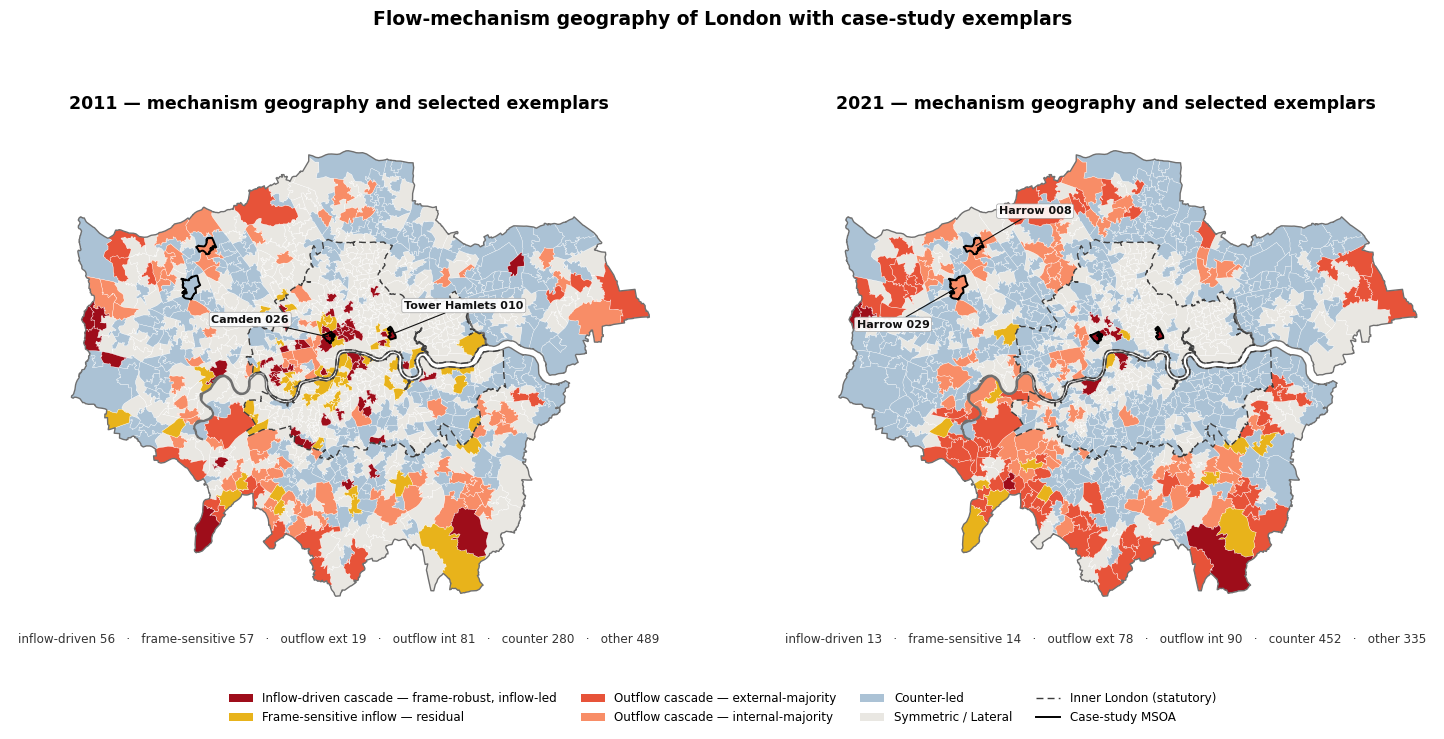

saved /Users/xing/Desktop/CASA/dissertation/outputs/case_study/locator_map/fig_eda10_v2_mechanism_case_locator_20260729.png


In [15]:
# ── Figure 4.5: two-panel mechanism geography with case exemplars ────────────
TITLES = {'11': '2011 — mechanism geography and selected exemplars',
          '21': '2021 — mechanism geography and selected exemplars'}

fig, axes = plt.subplots(1, 2, figsize=(15.5, 7.4))

for ax, yr in zip(axes, ('11', '21')):
    for c in FLOW_DRAW_ORDER:
        polys = [r for g, code in zip(geoms, codes)
                 if cat[yr].get(code, 'other') == c for r in rings(g)]
        if polys:
            ax.add_collection(PolyCollection(polys, facecolor=FLOW_FILL[c],
                                             edgecolor='white', linewidth=0.25,
                                             alpha=FLOW_ALPHA[c], zorder=2))
    for r in rings(london):
        ax.plot(r[:, 0], r[:, 1], color='#6f6f6f', lw=1.0, zorder=5)
    for r in rings(inner):
        ax.plot(r[:, 0], r[:, 1], color='#3d3d3d', lw=1.0, ls=(0, (5, 3)), zorder=5)

    for code, name in CASES.items():
        g = geoms[codes.index(code)]
        ax.add_collection(PolyCollection(rings(g), facecolor='none',
                                         edgecolor='black', linewidth=1.4, zorder=6))
        if yr in LABEL_YEARS.get(name, ()):
            cx, cy = g.centroid.x, g.centroid.y
            dx, dy = LABEL_OFF[name]
            ax.annotate(name, xy=(cx, cy), xytext=(cx + dx, cy + dy),
                        fontsize=8, fontweight='bold', color='#111',
                        ha='center', va='center', zorder=8,
                        arrowprops=dict(arrowstyle='-', color='#111', lw=0.8,
                                        shrinkA=0, shrinkB=1),
                        bbox=dict(boxstyle='round,pad=0.2', fc='white',
                                  ec='#999', lw=0.5, alpha=0.9))

    n = counts[yr]
    ax.set_title(TITLES[yr], fontsize=12.5, fontweight='bold', pad=8)
    ax.text(0.5, -0.015,
            f"inflow-driven {n.get('inflow-driven',0)}   ·   frame-sensitive {n.get('frame-sensitive',0)}   ·   "
            f"outflow ext {n.get('outflow-external',0)}   ·   outflow int {n.get('outflow-internal',0)}   ·   "
            f"counter {n.get('counter',0)}   ·   other {n.get('other',0)}",
            transform=ax.transAxes, ha='center', va='top', fontsize=8.6, color='#333')
    ax.set_aspect(1.0 / np.cos(np.radians(51.5)))
    ax.set_xlim(-0.60, 0.36); ax.set_ylim(51.26, 51.72)
    ax.set_axis_off()

handles = ([mpatches.Patch(fc=FLOW_FILL[c], alpha=FLOW_ALPHA[c], label=FLOW_LABEL[c])
            for c in ('inflow-driven', 'frame-sensitive', 'outflow-external',
                      'outflow-internal', 'counter', 'other')] +
           [Line2D([0], [0], color='#3d3d3d', lw=1.0, ls=(0, (5, 3)),
                   label='Inner London (statutory)'),
            Line2D([0], [0], color='black', lw=1.4, label='Case-study MSOA')])
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False,
           fontsize=8.6, bbox_to_anchor=(0.5, 0.005))

fig.suptitle('Flow-mechanism geography of London with case-study exemplars',
             fontsize=13.5, fontweight='bold', y=0.985)

plt.tight_layout(rect=[0, 0.085, 1, 0.95])
plt.savefig(OUT_PNG, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'saved {OUT_PNG}')

## Draft caption (end of §4.5)

> **Figure 4.5. Spatial distribution of Frame C mechanism profiles and selected
> case-study MSOAs, 2011 and 2021.** Area fills show the six-class flow
> classification from the EDA 9 time-symmetric tree (warm hues = cascade
> mechanism leaves; blue = Counter-led; grey = Symmetric/Lateral); per-panel
> counts beneath each map. Black outlines mark the four case-study MSOAs
> analysed in the text: the genuine-persistent pair Camden 026 and Tower
> Hamlets 010 (inflow-driven in both censuses, labelled on the 2011 panel) and
> the outflow-internal pair Harrow 008 and Harrow 029 (the national-ladder
> artefact, labelled on the 2021 panel). The colour scheme is identical to
> Figure 4.6, which overlays the independently derived Yee & Dennett (2022)
> subtype indicators on the same background.

## Notes

- The purple-marker correspondence map (**Figure 4.6**) is produced by
  `eda_12_v5_comparison_map_refined_20260729.ipynb` — remember to remove any
  case outlines/labels there (v5 already has none).
- `eda_10fixed` (eight/nine labelled cases) is retained unchanged as the
  **appendix** locator.
- If a leader line lands awkwardly on the real render, nudge the pair in
  `LABEL_OFF` — offsets are degrees lon/lat, as in eda_10fixed.